In [1]:
# --- Training vs Test Accuracy, Learning Curves, Cross-Validation ---
from sklearn.model_selection import cross_val_score, learning_curve
import numpy as np
import joblib
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load data (ensure X, y, X_train, X_test, y_train, y_test are defined)
df = pd.read_csv('../data/processed_dataset.csv')
X = df.drop('Health_Status', axis=1)
y = df['Health_Status']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [3]:
rf_path = '../models/random_forest_model.pkl' if os.path.exists('../models/random_forest_model.pkl') else '../../models/random_forest_model.pkl'
rf_model = joblib.load(rf_path)
# Load the SVM model trained on scaled data
svm_path = '../models/svm_model_scaled.pkl' if os.path.exists('../models/svm_model_scaled.pkl') else '../../models/svm_model_scaled.pkl'
svm_model = joblib.load(svm_path)

In [4]:
# 1. Print and compare training vs test accuracy
rf_train_acc = rf_model.score(X_train, y_train)
rf_test_acc = rf_model.score(X_test, y_test)
print(f"Random Forest - Training Accuracy: {rf_train_acc:.3f}, Test Accuracy: {rf_test_acc:.3f}")

Random Forest - Training Accuracy: 1.000, Test Accuracy: 0.983


In [5]:
# For SVM, scale features before scoring
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm_train_acc = svm_model.score(X_train_scaled, y_train)
svm_test_acc = svm_model.score(X_test_scaled, y_test)
print(f"SVM (scaled) - Training Accuracy: {svm_train_acc:.3f}, Test Accuracy: {svm_test_acc:.3f}")

SVM (scaled) - Training Accuracy: 0.998, Test Accuracy: 0.817


In [6]:
# 2. Plot learning curves for Random Forest
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X, y, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

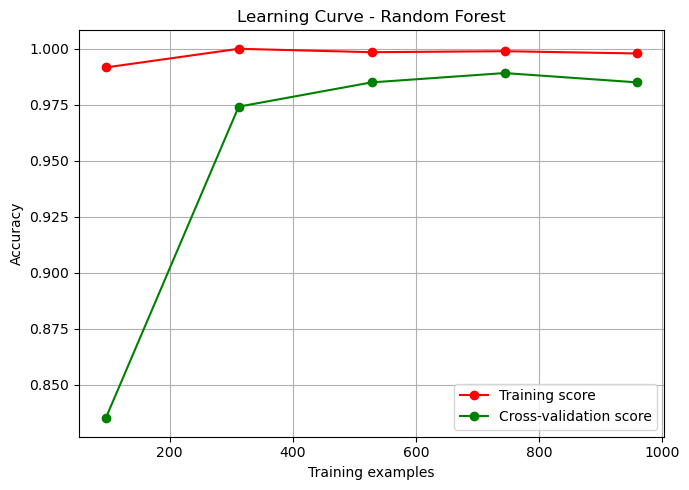

In [7]:
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
plt.title('Learning Curve - Random Forest')
plt.xlabel('Training examples')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid()
plt.tight_layout()
plt.show()

In [8]:
# 3. Cross-validation for more reliable estimates
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print(f"Random Forest - Cross-validated Accuracy: {rf_cv_scores.mean():.3f} ± {rf_cv_scores.std():.3f}")

Random Forest - Cross-validated Accuracy: 0.985 ± 0.012


In [9]:
# For SVM, use scaling for cross-validation
svm_cv_scores = cross_val_score(svm_model, scaler.transform(X), y, cv=5, scoring='accuracy')
print(f"SVM (scaled) - Cross-validated Accuracy: {svm_cv_scores.mean():.3f} ± {svm_cv_scores.std():.3f}")

SVM (scaled) - Cross-validated Accuracy: 0.856 ± 0.024
